# Subject 4: Prediction of the Critical Temperature of Superconducting Materials

This notebook is the clean code submission for the statistical learning project.
The objective is to predict the critical temperature `critical_temp` from 81
physical and chemical covariates in the UCI superconductivity dataset.

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

## Reproducible Pipeline

The notebook delegates implementation to reusable Python modules and scripts.
This avoids duplicating notebook-only logic and keeps preprocessing, model
selection, and evaluation reproducible.

In [2]:
for command in [
    [sys.executable, "scripts/run_eda.py"],
    [sys.executable, "scripts/train_models.py"],
    [sys.executable, "scripts/evaluate_models.py"],
]:
    print("$", " ".join(command))
    subprocess.run(command, check=True, cwd=PROJECT_ROOT)

$ /home/march/Projects/stat-learn-project/.venv/bin/python3 scripts/run_eda.py


2026-05-11 14:58:23,357 | INFO | run_eda | Caching/loading dataset
2026-05-11 14:58:23,357 | INFO | run_eda | Processed dataset path: /home/march/Projects/stat-learn-project/data/processed/superconductivity_clean.csv


2026-05-11 14:58:25,097 | INFO | run_eda | EDA completed successfully
$ /home/march/Projects/stat-learn-project/.venv/bin/python3 scripts/train_models.py


2026-05-11 14:58:25,834 | INFO | train_models | Loading processed dataset from /home/march/Projects/stat-learn-project/data/processed/superconductivity_clean.csv
2026-05-11 14:58:25,941 | INFO | train_models | Data ready: 21197 rows, 81 numeric features, train=16957 rows, test=4240 rows
2026-05-11 14:58:25,941 | INFO | train_models | Using metric function from src.evaluation: evaluate_regression_metrics
2026-05-11 14:58:25,941 | INFO | train_models | Training model: dummy_regressor
2026-05-11 14:58:25,944 | INFO | train_models | Saved fitted model to /home/march/Projects/stat-learn-project/artifacts/models/dummy_regressor.joblib
2026-05-11 14:58:25,944 | INFO | train_models | Training model: linear_regression
2026-05-11 14:58:26,006 | INFO | train_models | Saved fitted model to /home/march/Projects/stat-learn-project/artifacts/models/linear_regression.joblib
2026-05-11 14:58:26,006 | INFO | train_models | Training model: ridge_cv


2026-05-11 14:58:26,356 | INFO | train_models | Saved fitted model to /home/march/Projects/stat-learn-project/artifacts/models/ridge_cv.joblib
2026-05-11 14:58:26,356 | INFO | train_models | Training model: lasso_cv


...

2026-05-11 14:58:36,647 | INFO | train_models | Saved fitted model to /home/march/Projects/stat-learn-project/artifacts/models/hist_gradient_boosting.joblib
2026-05-11 14:58:36,681 | INFO | train_models | Saved model bundle to /home/march/Projects/stat-learn-project/artifacts/models/model_bundle.joblib


2026-05-11 14:58:36,964 | INFO | train_models | Saved predictions table to /home/march/Projects/stat-learn-project/reports/tables/model_predictions.csv
2026-05-11 14:58:36,964 | INFO | train_models | Saved comparison table to /home/march/Projects/stat-learn-project/reports/tables/model_comparison.csv
2026-05-11 14:58:36,964 | INFO | train_models | Training workflow completed successfully.


$ /home/march/Projects/stat-learn-project/.venv/bin/python3 scripts/evaluate_models.py


2026-05-11 14:58:38,301 | INFO | __main__ | Loading predictions from /home/march/Projects/stat-learn-project/reports/tables/model_predictions.csv


2026-05-11 14:58:38,942 | INFO | __main__ | Best model by RMSE: knn_gridsearch (RMSE=10.657041)
2026-05-11 14:58:38,942 | INFO | __main__ | Wrote comparison tables: /home/march/Projects/stat-learn-project/reports/tables/final_model_comparison.csv and /home/march/Projects/stat-learn-project/reports/tables/final_model_comparison.tex
2026-05-11 14:58:38,942 | INFO | __main__ | Wrote residual diagnostics: /home/march/Projects/stat-learn-project/reports/tables/final_model_residuals.csv, /home/march/Projects/stat-learn-project/reports/tables/final_model_residuals_summary.csv, /home/march/Projects/stat-learn-project/reports/tables/final_model_residuals_summary.tex
2026-05-11 14:58:38,942 | INFO | __main__ | Wrote diagnostic figures: /home/march/Projects/stat-learn-project/reports/figures/best_model_predicted_vs_observed.png and /home/march/Projects/stat-learn-project/reports/figures/best_model_residual_diagnostics.png


## Dataset Overview

In [3]:
preprocessing = pd.read_json(
    PROJECT_ROOT / "reports/tables/preprocessing_summary.json",
    typ="series",
)
overview = pd.read_json(
    PROJECT_ROOT / "reports/tables/dataset_overview.json",
    typ="series",
)
target_summary = pd.read_json(
    PROJECT_ROOT / "reports/tables/target_summary.json",
    typ="series",
)
display(preprocessing.to_frame("value"))
display(overview.to_frame("value"))
display(target_summary.to_frame("value"))

,value
raw_rows,21263
processed_rows,21197
duplicate_rows_removed,66
missing_values_after_cleaning,0


,value
n_rows,21197
n_columns,82
n_features,81
n_numeric_features,81
target,critical_temp
missing_values_total,0
duplicate_rows,0


,value
count,21197.000000
mean,34.494532
std,34.276465
min,0.000210
q25,5.380000
median,20.000000
q75,63.000000
max,185.000000
skew,0.855900


The raw table contains exact duplicate rows, which are removed before the
train-test split. The processed table has no missing values. The target is positive
and right-skewed, so the modeling pipeline uses a `log1p` target transformation and
reports final errors after transforming predictions back to Kelvin.

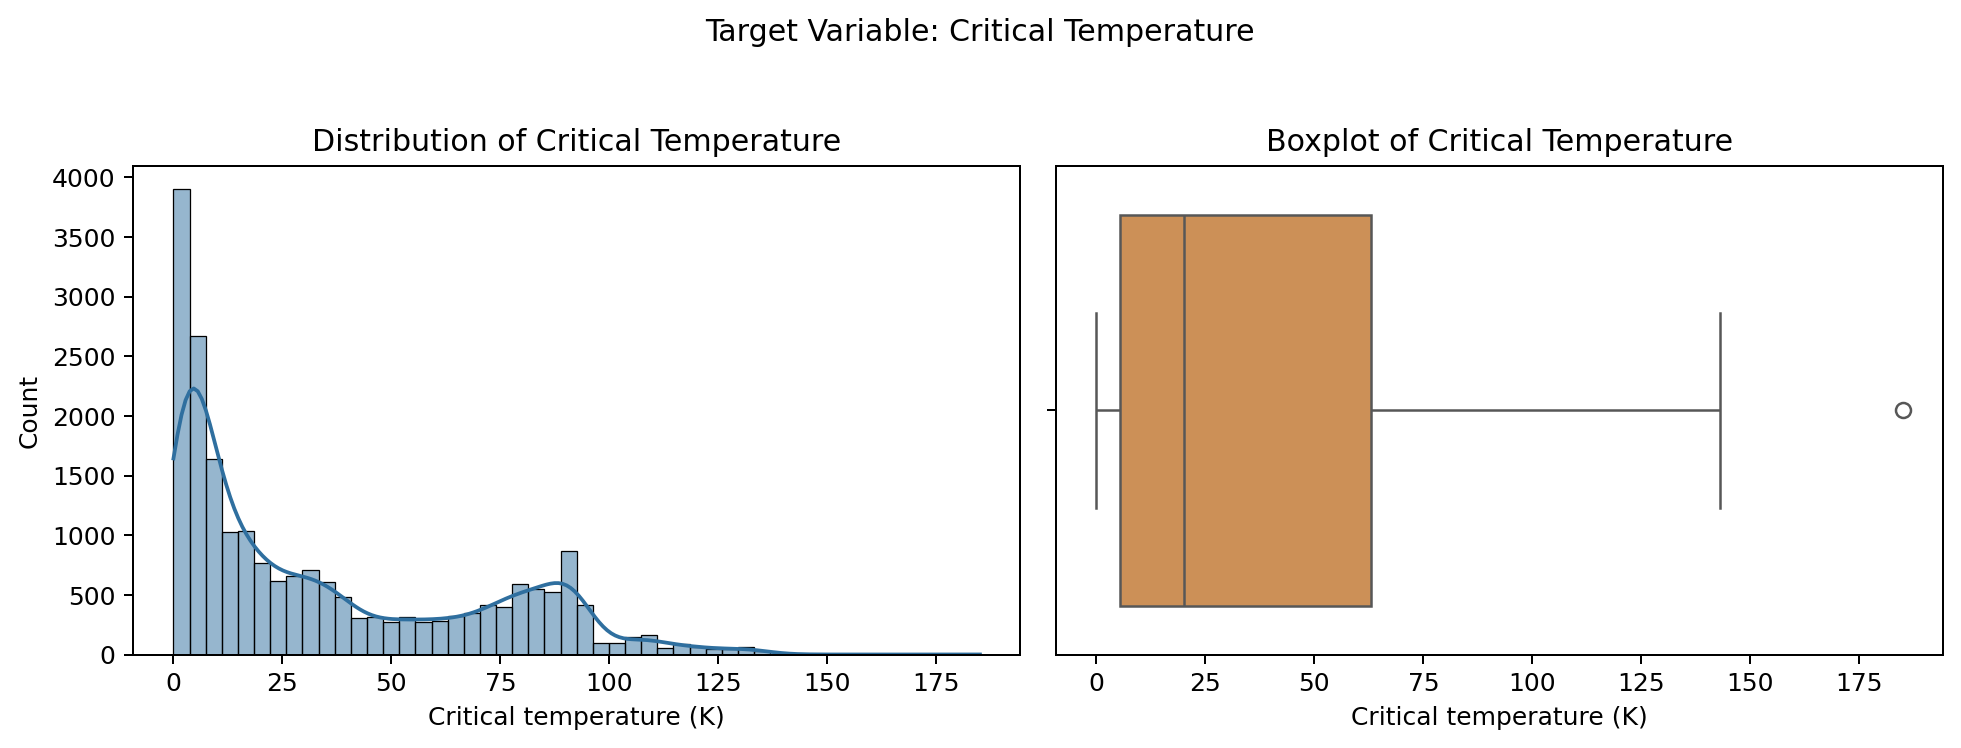

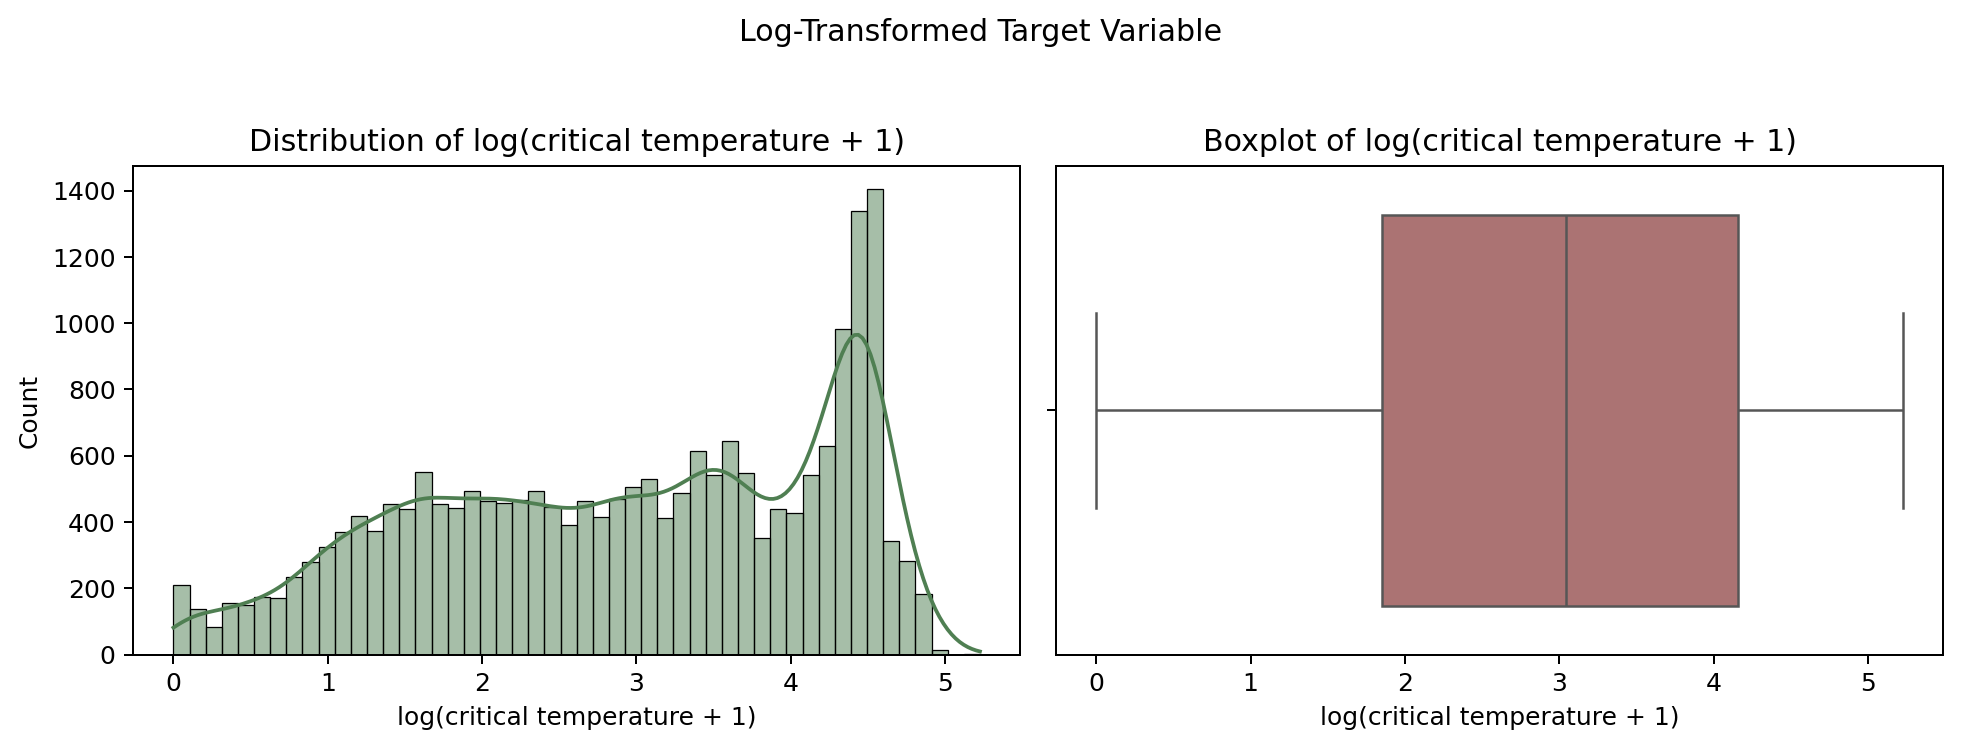

In [4]:
for figure in [
    "reports/figures/target_distribution.png",
    "reports/figures/log_target_distribution.png",
]:
    display(Image(filename=str(PROJECT_ROOT / figure)))

## Exploratory Feature Analysis

,feature,correlation,abs_correlation
0,wtd_std_ThermalConductivity,0.720960,0.720960
1,range_ThermalConductivity,0.687282,0.687282
2,range_atomic_radius,0.653394,0.653394
3,std_ThermalConductivity,0.653232,0.653232
4,wtd_mean_Valence,-0.631924,0.631924
5,wtd_entropy_atomic_mass,0.626536,0.626536
6,wtd_gmean_Valence,-0.615130,0.615130
7,wtd_entropy_atomic_radius,0.602986,0.602986
8,number_of_elements,0.600394,0.600394
9,range_fie,0.600179,0.600179


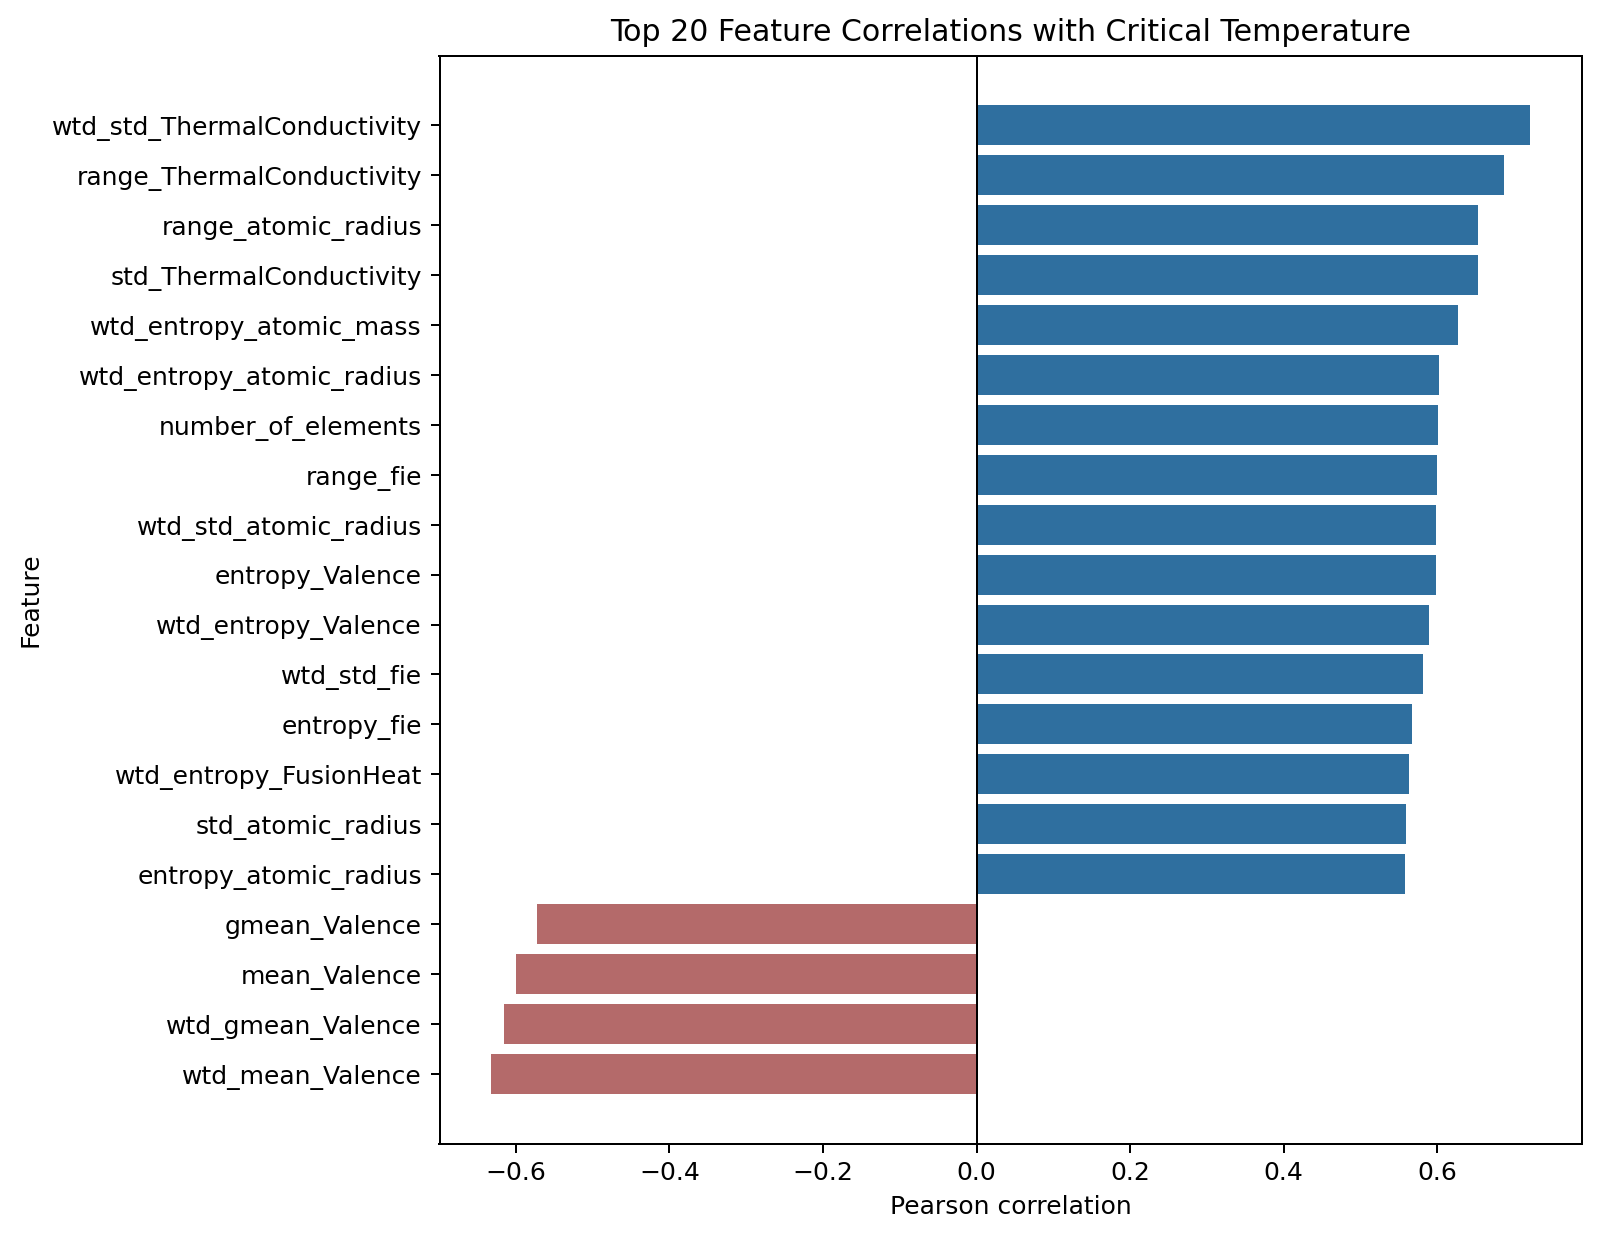

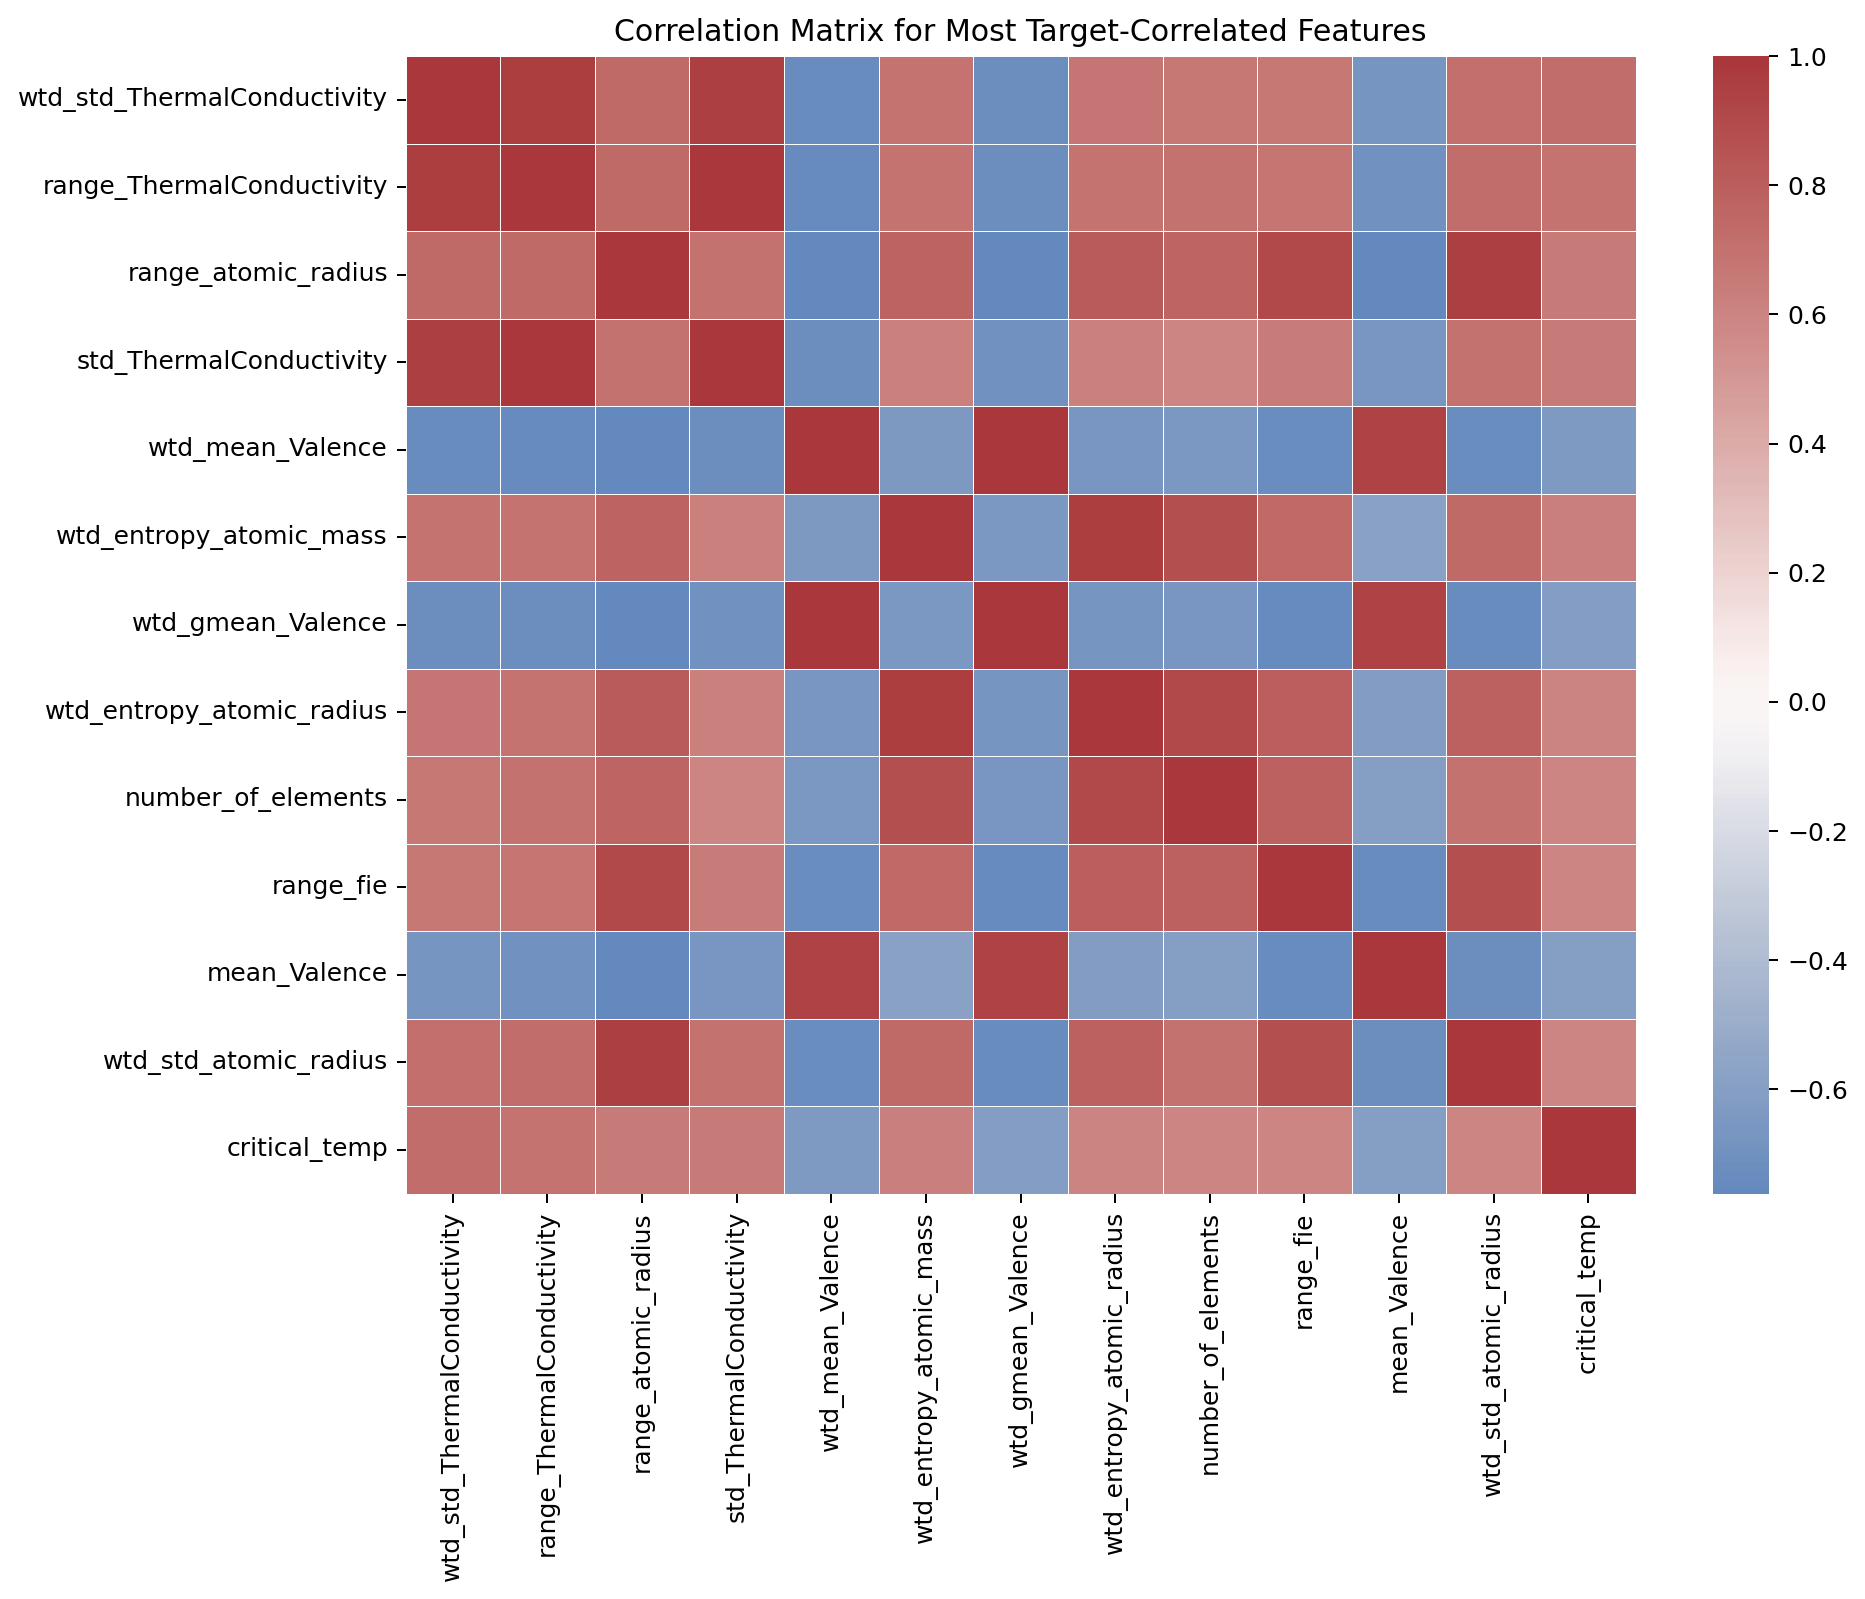

In [5]:
correlations = pd.read_csv(
    PROJECT_ROOT / "reports/tables/feature_target_correlations.csv"
)
display(correlations.head(15))

for figure in [
    "reports/figures/feature_target_correlations.png",
    "reports/figures/selected_feature_correlation_matrix.png",
]:
    display(Image(filename=str(PROJECT_ROOT / figure)))

## Model Comparison

The final comparison below is computed only on the held-out test set. Hyperparameters
are selected inside the training data by cross-validation where applicable.

In [6]:
comparison = pd.read_csv(PROJECT_ROOT / "reports/tables/final_model_comparison.csv")
display(comparison)

,model,mse,rmse,mae,r2
0,knn_gridsearch,113.572521,10.657041,5.674742,0.903519
1,hist_gradient_boosting,115.456973,10.745091,6.291585,0.901918
2,ridge_cv,334.880074,18.299729,12.475219,0.715515
3,linear_regression,334.909282,18.300527,12.474248,0.715491
4,lasso_cv,336.183164,18.335298,12.520908,0.714408
5,dummy_regressor,1469.034170,38.327982,27.668923,-0.247962


## Diagnosis of the Recommended Model

The recommended model is the one with the smallest test RMSE. Residual plots are used
to check whether the error pattern reveals major systematic failures.

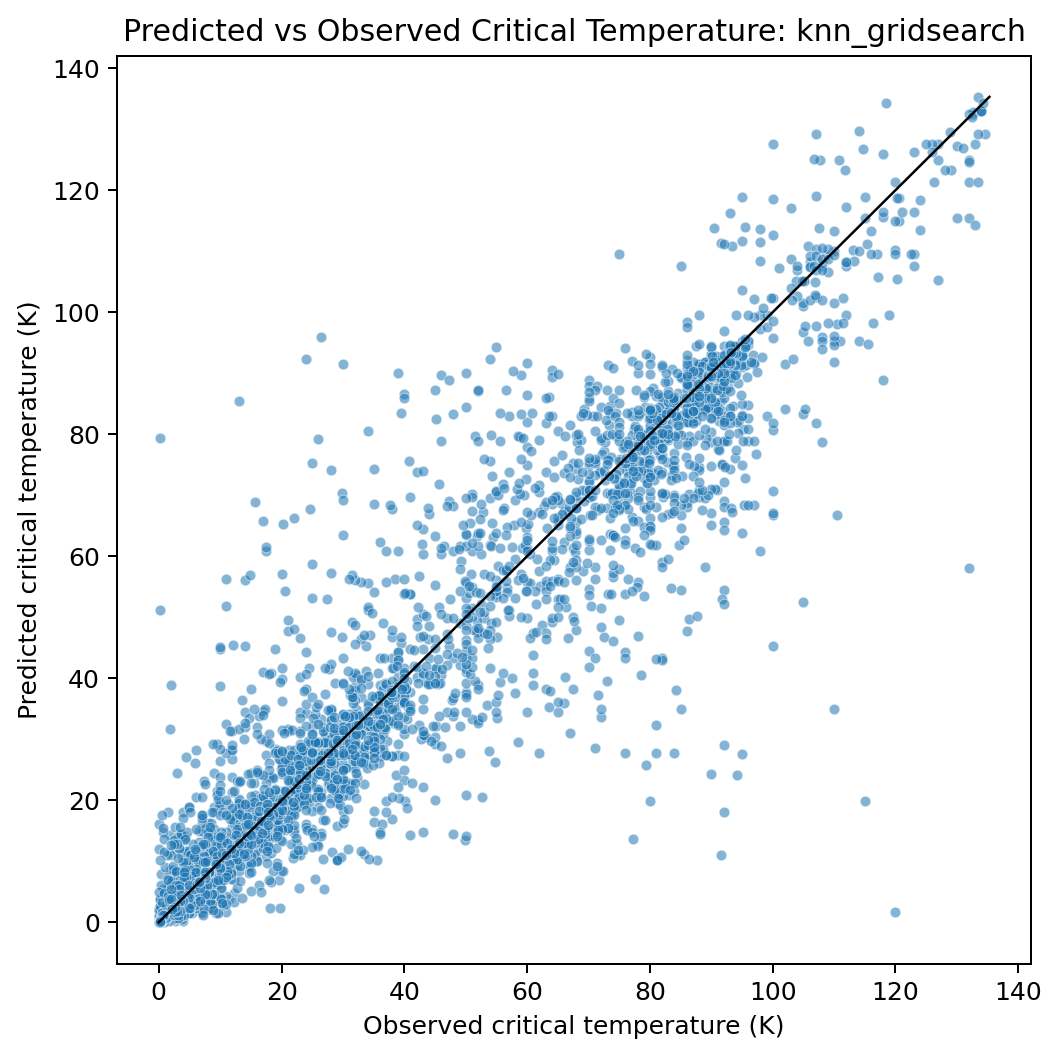

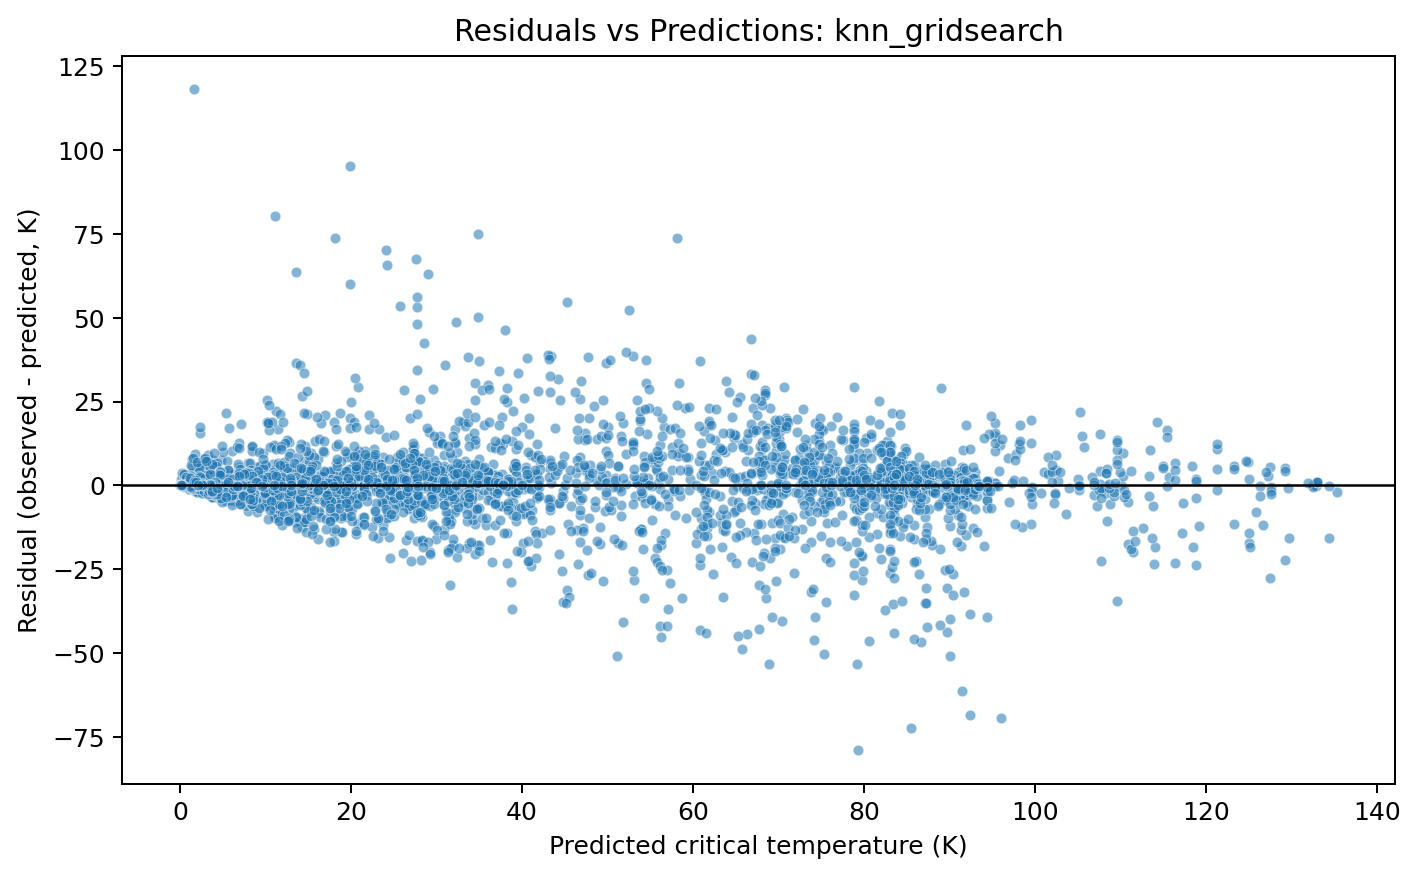

In [7]:
for figure in [
    "reports/figures/best_model_predicted_vs_observed.png",
    "reports/figures/best_model_residual_diagnostics.png",
]:
    display(Image(filename=str(PROJECT_ROOT / figure)))

## Conclusion

On the cleaned table, k-NN regression gives the lowest held-out RMSE in this run,
narrowly ahead of `HistGradientBoostingRegressor` and clearly ahead of OLS, Ridge,
and Lasso. Ridge, Lasso, k-NN, and the general evaluation framework are covered by
the course material; the gradient boosting model is included as one additional
nonlinear benchmark and must be explained explicitly in the written report.